In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
import sys as sys
import scipy as sp
from scipy import linalg
from newmark import newmark
# FEM matrices
npzfile = np.load("owt_XKM.npz")
X = npzfile["X"]
M = np.asarray(npzfile["M"], dtype=float)
K = np.asarray(npzfile["K"], dtype=float)

ndof = M.shape[0]
print(f"Number of DOFs: {ndof}")

# Natural frequencies and mode shapes
n_modes = min(100, ndof)
lam, U = linalg.eigh(K, M, subset_by_index=[0, n_modes - 1])

omega = np.sqrt(np.real(lam))
freq = omega / (2 * np.pi)

# Rayleigh damping
zeta = 0.025
omega_ref = omega[12]  # Mode 13

aR = zeta * omega_ref
bR = zeta / omega_ref

C = aR * M + bR * K

print("First frequencies [Hz]:")
print(freq[:15])

Number of DOFs: 1674
First frequencies [Hz]:
[0.18480029 0.18562756 0.40530079 0.42204775 0.43899105 0.57192572
 0.61689729 0.62078803 1.06751439 1.14817615 1.25640542 1.33217439
 1.45702691 1.69042457 1.70138568]


In [2]:
# Time settings
dt = 0.001
t_end = 20.0
time = np.arange(0.0, t_end + dt, dt)
n_steps = len(time)

# Force location: Node 50, Y-direction
force_node = 50
force_dof = (force_node - 1) * 6 + 1  # zero-based index

# Continuous-time state-space model
Ac = np.zeros((2 * ndof, 2 * ndof))
Ac[:ndof, ndof:] = np.eye(ndof)

Ac[ndof:, :ndof] = -linalg.solve(M, K)
Ac[ndof:, ndof:] = -linalg.solve(M, C)

# Unit force input
Bc = np.zeros((2 * ndof, 1))
Bc[ndof:, 0] = linalg.solve(M, np.eye(ndof)[:, force_dof])

# Exact zero-order-hold discretization
augmented = np.zeros((2 * ndof + 1, 2 * ndof + 1))
augmented[:2 * ndof, :2 * ndof] = Ac
augmented[:2 * ndof, -1:] = Bc

discrete = linalg.expm(augmented * dt)

A = discrete[:2 * ndof, :2 * ndof]
B = discrete[:2 * ndof, -1:]

print("A shape:", A.shape)
print("B shape:", B.shape)

A shape: (3348, 3348)
B shape: (3348, 1)


In [3]:
# Only these DOFs are saved and plotted
selected_nodes = [41]
selected_direction = 2  # 1=X, 2=Y, 3=Z

selected_dofs = np.array(
    [(node - 1) * 6 + selected_direction - 1 for node in selected_nodes],
    dtype=int,
)

# Output-selection matrix
H = np.zeros((len(selected_dofs), ndof))
H[np.arange(len(selected_dofs)), selected_dofs] = 1.0

print("Selected DOFs:", selected_dofs)

Selected DOFs: [241]


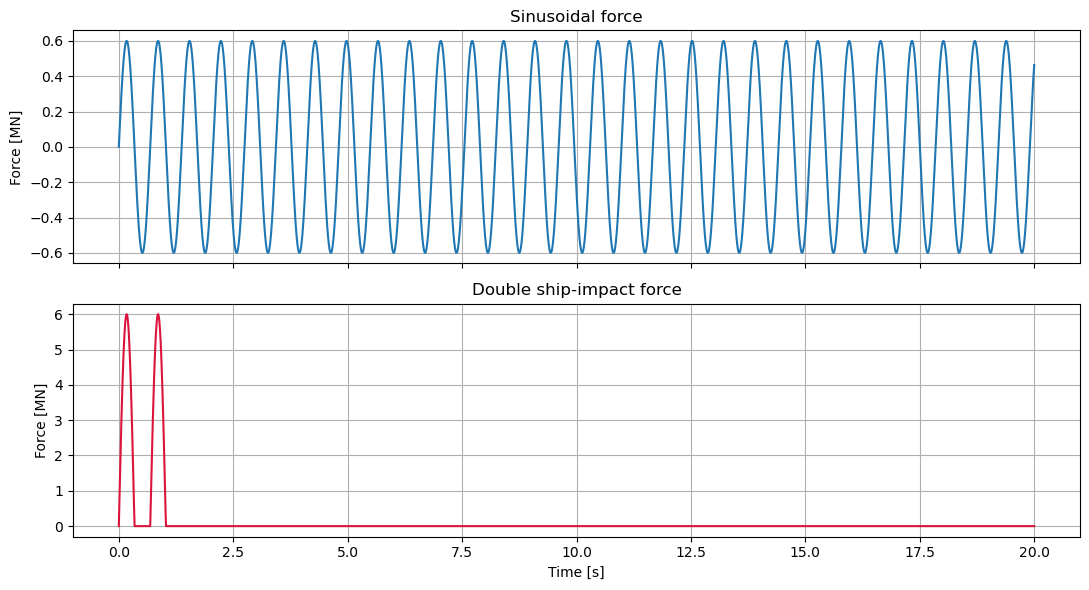

In [4]:
# Scenario 1: sinusoidal force
F0 = 0.6e6
forcing_omega = omega[12]  # Mode 13

p_sine = F0 * np.sin(forcing_omega * time)

# Scenario 2: double ship-impact force
impact_amplitude = 10.0 * F0
impact_period = 2.0 * np.pi / forcing_omega

p_ship = np.zeros_like(time)

mask_1 = (time >= 0.0) & (time <= 0.5 * impact_period)
mask_2 = (time >= impact_period) & (time <= 1.5 * impact_period)

p_ship[mask_1] = impact_amplitude * np.sin(
    np.pi * time[mask_1] / (0.5 * impact_period)
)

p_ship[mask_2] = impact_amplitude * np.sin(
    np.pi * (time[mask_2] - impact_period) / (0.5 * impact_period)
)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(time, p_sine * 1e-6)
axes[0].set_ylabel("Force [MN]")
axes[0].set_title("Sinusoidal force")
axes[0].grid(True)

axes[1].plot(time, p_ship * 1e-6, color="crimson")
axes[1].set_ylabel("Force [MN]")
axes[1].set_xlabel("Time [s]")
axes[1].set_title("Double ship-impact force")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
def simulate_state_space(force_history, y0=None, v0=None):
    """Simulate the full system while storing only selected DOFs."""

    y0 = np.zeros(ndof) if y0 is None else np.asarray(y0, dtype=float)
    v0 = np.zeros(ndof) if v0 is None else np.asarray(v0, dtype=float)

    # Internal full state; only one time step is retained
    z_current = np.hstack((y0, v0))

    # Stored output: [selected displacement; selected velocity]
    z_selected = np.zeros((2 * len(selected_dofs), n_steps))
    z_selected[:len(selected_dofs), 0] = H @ y0
    z_selected[len(selected_dofs):, 0] = H @ v0

    for k in range(n_steps - 1):
        z_current = A @ z_current + B[:, 0] * force_history[k]

        displacement = z_current[:ndof]
        velocity = z_current[ndof:]

        z_selected[:len(selected_dofs), k + 1] = H @ displacement
        z_selected[len(selected_dofs):, k + 1] = H @ velocity

    return z_selected

In [6]:
# Forced responses
z_sine = simulate_state_space(p_sine)
z_ship = simulate_state_space(p_ship)

# Free vibration initial condition
y0_free = np.zeros(ndof)
v0_free = np.zeros(ndof)

# Small initial displacement at the force DOF
y0_free[force_dof] = 1e-3

p_free = np.zeros(n_steps)
z_free = simulate_state_space(p_free, y0_free, v0_free)

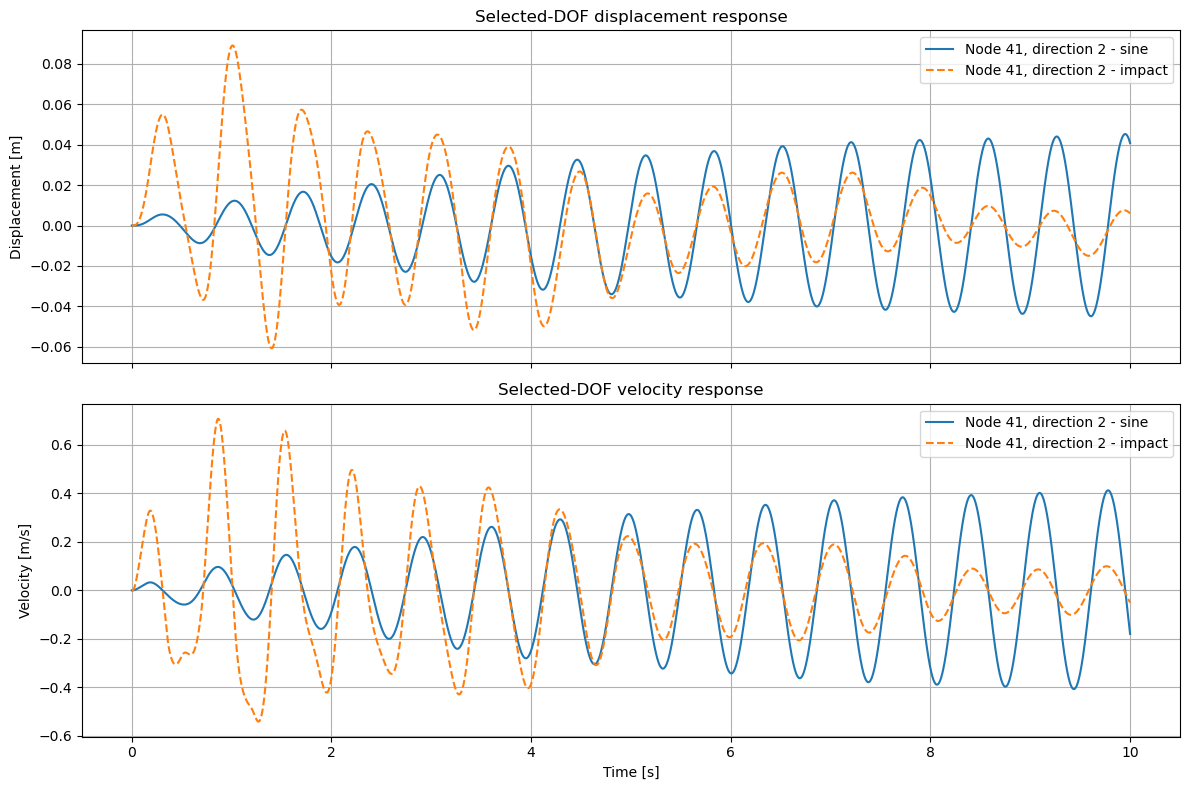

In [7]:
n_selected = len(selected_dofs)

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True
)

selected_nodes = [41]
for i, node in enumerate(selected_nodes):
    label = f"Node {node}, direction {selected_direction}"

    # only show the first 10 sec
    time_mask = time <= 10.0
    axes[0].plot(time[time_mask], z_sine[i, :][time_mask], label=f"{label} - sine")
    axes[0].plot(time[time_mask], z_ship[i, :][time_mask], "--", label=f"{label} - impact")

    axes[1].plot(
        time[time_mask],
        z_sine[n_selected + i, :][time_mask],
        label=f"{label} - sine",
    )
    axes[1].plot(
        time[time_mask],
        z_ship[n_selected + i, :][time_mask],
        "--",
        label=f"{label} - impact",
    )


axes[0].set_ylabel("Displacement [m]")
axes[0].set_title("Selected-DOF displacement response")
axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_xlabel("Time [s]")
axes[1].set_title("Selected-DOF velocity response")

for ax in axes:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
print(f"Number of modes included: {n_modes}")

Number of modes included: 100


In [10]:
from timestep import timestep

### MODAL RESPONSES
t0 = 0.0
N = n_steps - 1

# Modal mass and stiffness
mm = U[:, :n_modes].T @ M @ U[:, :n_modes]
km = U[:, :n_modes].T @ K @ U[:, :n_modes]

# Modal force histories.
# p_sine and p_ship are scalar force histories applied at force_dof.
fj_sin_all = U[force_dof, :n_modes, None] * p_sine[None, :]
fj_imp_all = U[force_dof, :n_modes, None] * p_ship[None, :]

# Response storage
r_sin = np.zeros((n_modes, n_steps))
dr_sin = np.zeros((n_modes, n_steps))
ddr_sin = np.zeros((n_modes, n_steps))

r_imp = np.zeros((n_modes, n_steps))
dr_imp = np.zeros((n_modes, n_steps))
ddr_imp = np.zeros((n_modes, n_steps))

for j in range(n_modes):
    mj = mm[j, j]
    kj = km[j, j]
    cj = 2.0 * zeta * np.sqrt(mj * kj)

    r_sin[j], dr_sin[j], ddr_sin[j], _, _ = timestep(
        mj, cj, kj,
        0.0, 0.0,
        t0, dt, N,
        fj_sin_all[j],
    )

    r_imp[j], dr_imp[j], ddr_imp[j], _, _ = timestep(
        mj, cj, kj,
        0.0, 0.0,
        t0, dt, N,
        fj_imp_all[j],
    )

In [11]:
import matplotlib.pyplot as plt

# Reconstruct modal responses at the selected physical DOFs
Phi_selected = U[selected_dofs, :n_modes]

modal_disp_sine = Phi_selected @ r_sin
modal_vel_sine = Phi_selected @ dr_sin

modal_disp_ship = Phi_selected @ r_imp
modal_vel_ship = Phi_selected @ dr_imp

n_selected = len(selected_dofs)

# Time mask (Plots first 5 seconds)
time_mask = time <= 5.0
t_plot = time[time_mask]

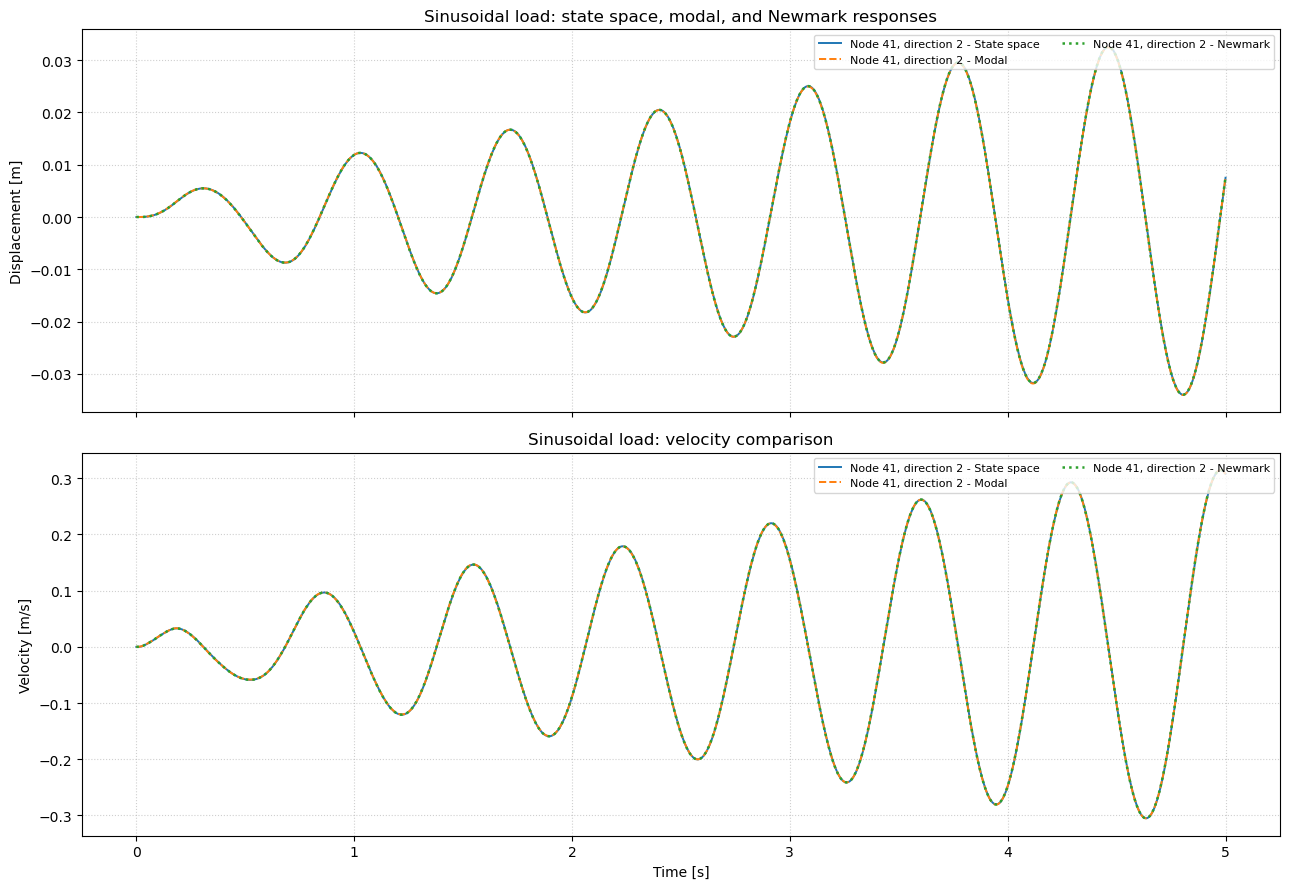

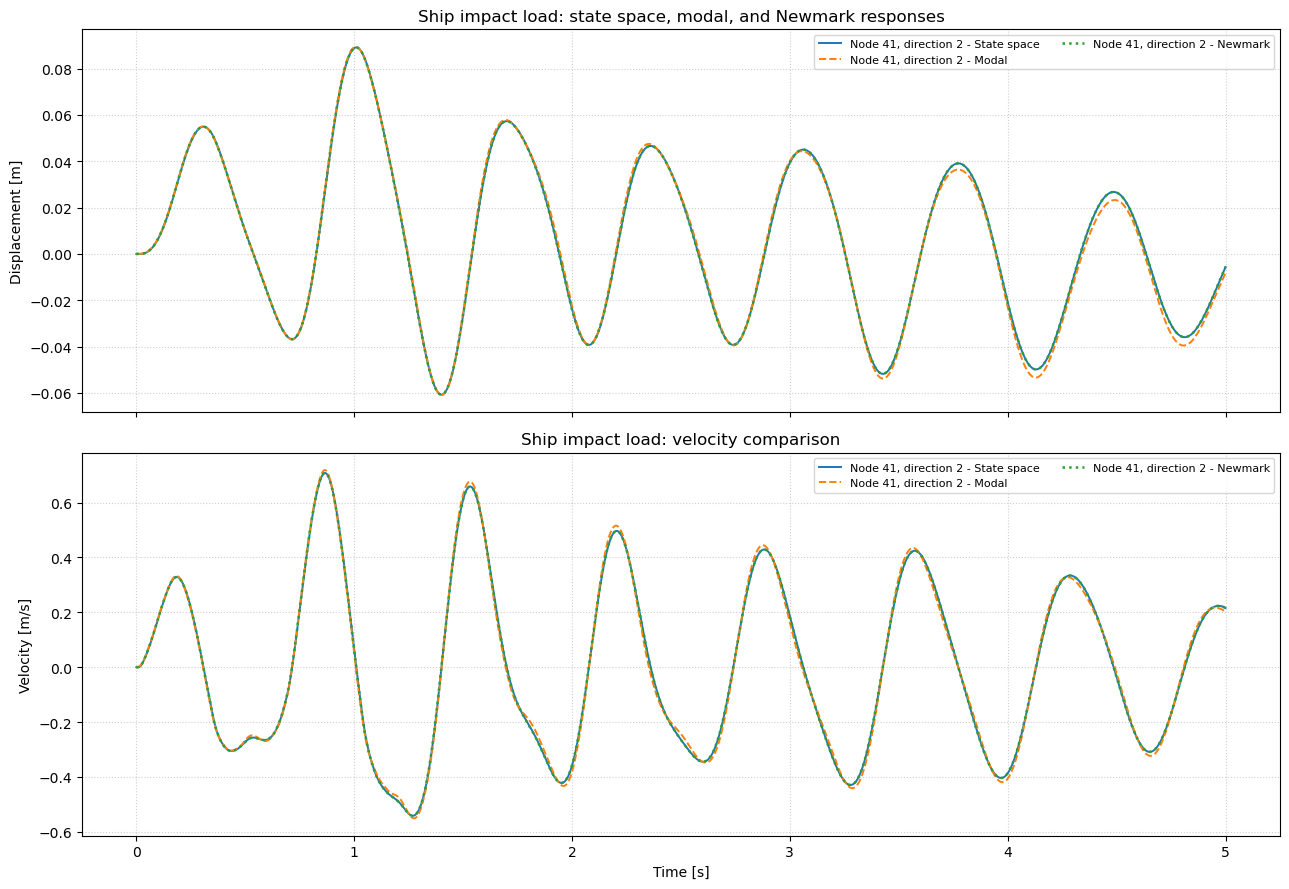

In [12]:
# Full-system Newmark responses and three-way comparison
F_sine = np.zeros((ndof, n_steps))
F_ship = np.zeros((ndof, n_steps))
F_sine[force_dof, :] = p_sine
F_ship[force_dof, :] = p_ship

x0_newmark = np.zeros(ndof)
v0_newmark = np.zeros(ndof)

newmark_sine, newmark_vel_sine, _, _, = newmark(
    K, C, M, x0_newmark, v0_newmark, dt, n_steps - 1, F_sine
)
newmark_ship, newmark_vel_ship, _, _, = newmark(
    K, C, M, x0_newmark, v0_newmark, dt, n_steps - 1, F_ship
)

newmark_disp_sine = H @ newmark_sine
newmark_vel_sine_selected = H @ newmark_vel_sine
newmark_disp_ship = H @ newmark_ship
newmark_vel_ship_selected = H @ newmark_vel_ship

comparison_nodes = [
    (dof // 6) + 1
    for dof in selected_dofs
]
comparison_labels = [
    f"Node {node}, direction {selected_direction}"
    for node in comparison_nodes
]

comparison_mask = time <= 5.0
t_compare = time[comparison_mask]

fig3, axes3 = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for i, label in enumerate(comparison_labels):
    axes3[0].plot(
        t_compare,
        z_sine[i, comparison_mask],
        label=f"{label} - State space",
        linewidth=1.4,
    )
    axes3[0].plot(
        t_compare,
        modal_disp_sine[i, comparison_mask],
        "--",
        label=f"{label} - Modal",
        linewidth=1.4,
    )
    axes3[0].plot(
        t_compare,
        newmark_disp_sine[i, comparison_mask],
        ":",
        label=f"{label} - Newmark",
        linewidth=1.8,
    )

    axes3[1].plot(
        t_compare,
        z_sine[len(selected_dofs) + i, comparison_mask],
        label=f"{label} - State space",
        linewidth=1.4,
    )
    axes3[1].plot(
        t_compare,
        modal_vel_sine[i, comparison_mask],
        "--",
        label=f"{label} - Modal",
        linewidth=1.4,
    )
    axes3[1].plot(
        t_compare,
        newmark_vel_sine_selected[i, comparison_mask],
        ":",
        label=f"{label} - Newmark",
        linewidth=1.8,
    )

axes3[0].set_title("Sinusoidal load: state space, modal, and Newmark responses")
axes3[0].set_ylabel("Displacement [m]")
axes3[1].set_title("Sinusoidal load: velocity comparison")
axes3[1].set_ylabel("Velocity [m/s]")
axes3[1].set_xlabel("Time [s]")
for ax in axes3:
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
fig3.tight_layout()

fig4, axes4 = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for i, label in enumerate(comparison_labels):
    axes4[0].plot(
        t_compare,
        z_ship[i, comparison_mask],
        label=f"{label} - State space",
        linewidth=1.4,
    )
    axes4[0].plot(
        t_compare,
        modal_disp_ship[i, comparison_mask],
        "--",
        label=f"{label} - Modal",
        linewidth=1.4,
    )
    axes4[0].plot(
        t_compare,
        newmark_disp_ship[i, comparison_mask],
        ":",
        label=f"{label} - Newmark",
        linewidth=1.8,
    )

    axes4[1].plot(
        t_compare,
        z_ship[len(selected_dofs) + i, comparison_mask],
        label=f"{label} - State space",
        linewidth=1.4,
    )
    axes4[1].plot(
        t_compare,
        modal_vel_ship[i, comparison_mask],
        "--",
        label=f"{label} - Modal",
        linewidth=1.4,
    )
    axes4[1].plot(
        t_compare,
        newmark_vel_ship_selected[i, comparison_mask],
        ":",
        label=f"{label} - Newmark",
        linewidth=1.8,
    )

axes4[0].set_title("Ship impact load: state space, modal, and Newmark responses")
axes4[0].set_ylabel("Displacement [m]")
axes4[1].set_title("Ship impact load: velocity comparison")
axes4[1].set_ylabel("Velocity [m/s]")
axes4[1].set_xlabel("Time [s]")
for ax in axes4:
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
fig4.tight_layout()

plt.show()

In [13]:
# Save state-space responses for later use
import pickle


state_space_responses = {
    "time": time,
    "sinusoidal_force": p_sine,
    "ship_impact_force": p_ship,
    "z_sine": z_sine,
    "z_ship": z_ship,
    "z_free": z_free,
    "selected_dofs": selected_dofs,
    "selected_nodes": selected_nodes,
    "selected_direction": selected_direction,
    "force_node": force_node,
    "force_dof": force_dof,
    "dt": dt,
    "M": M,
    "K": K,
    "C": C,
}

pickle_path = "data_wind_turbine.pkl"
with open(pickle_path, "wb") as pickle_file:
    pickle.dump(state_space_responses, pickle_file, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved state-space responses to {pickle_path}")


Saved state-space responses to data_wind_turbine.pkl
